In [1]:
import pandas as pd

df = pd.read_csv("budget_buddy_master_dataset.csv")

df.head()

,date,amount,category,payment_method,income,food,transport,shopping,savings,budget,day_type
0,1991-01-01,907.65,Bills & Utilities,Credit (Amex),13560.0,226.91,90.76,272.29,2284.59,10170.0,Weekday
1,1991-07-01,1122.15,Shopping,Debit (Mastercard),14081.2,280.54,112.22,336.65,1974.60,10560.9,Weekday
2,1991-12-01,366.30,Shopping,Credit (Discover),2920.0,91.58,36.63,109.89,640.49,2190.0,Weekend
3,1992-11-01,170.66,Bills & Utilities,Debit (Visa),1253.6,42.66,17.07,51.20,142.04,940.2,Weekend
4,1992-12-01,97.35,Shopping,Credit (Mastercard),1360.0,24.34,9.74,29.20,163.20,1020.0,Weekday


In [2]:
!pip install xgboost

In [3]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    classification_report,
    silhouette_score
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans

from xgboost import XGBRegressor

import joblib

In [4]:
# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("budget_buddy_master_dataset.csv")

print(df.head())

print("\nDataset Shape:")
print(df.shape)

         date   amount           category       payment_method   income  \
0  1991-01-01   907.65  Bills & Utilities        Credit (Amex)  13560.0   
1  1991-07-01  1122.15           Shopping   Debit (Mastercard)  14081.2   
2  1991-12-01   366.30           Shopping    Credit (Discover)   2920.0   
3  1992-11-01   170.66  Bills & Utilities         Debit (Visa)   1253.6   
4  1992-12-01    97.35           Shopping  Credit (Mastercard)   1360.0   

     food  transport  shopping  savings   budget day_type  
0  226.91      90.76    272.29  2284.59  10170.0  Weekday  
1  280.54     112.22    336.65  1974.60  10560.9  Weekday  
2   91.58      36.63    109.89   640.49   2190.0  Weekend  
3   42.66      17.07     51.20   142.04    940.2  Weekend  
4   24.34       9.74     29.20   163.20   1020.0  Weekday  

Dataset Shape:
(11115, 11)


In [5]:
# =========================
# DATASET INFORMATION
# =========================

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11115 entries, 0 to 11114
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            11115 non-null  object 
 1   amount          11115 non-null  float64
 2   category        11115 non-null  object 
 3   payment_method  11115 non-null  object 
 4   income          11115 non-null  float64
 5   food            11115 non-null  float64
 6   transport       11115 non-null  float64
 7   shopping        11115 non-null  float64
 8   savings         11115 non-null  float64
 9   budget          11115 non-null  float64
 10  day_type        11115 non-null  object 
dtypes: float64(7), object(4)
memory usage: 955.3+ KB
None

Missing Values:
date              0
amount            0
category          0
payment_method    0
income            0
food              0
transport         0
shopping          0
savings           0
budget            0
day_type          0
dtype: int

In [6]:
# =========================
# DATA CLEANING
# =========================

# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Convert date column
df['date'] = pd.to_datetime(df['date'])

print("Cleaned Dataset Shape:")
print(df.shape)

Cleaned Dataset Shape:
(11115, 11)


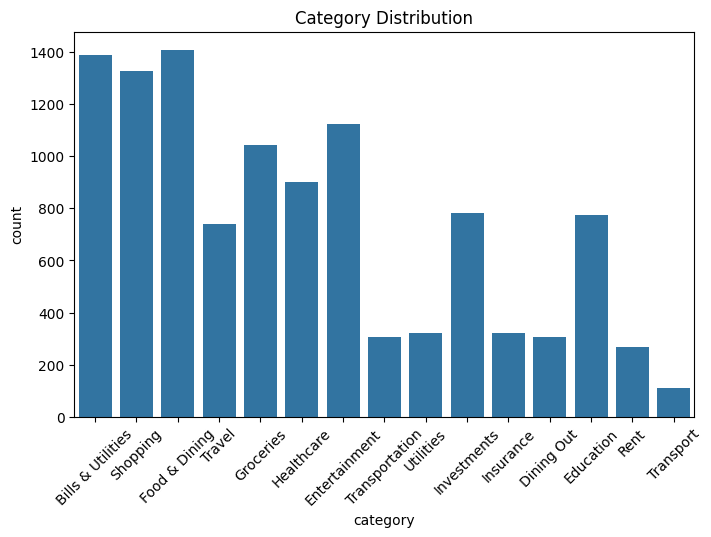

In [7]:
# =========================
# CATEGORY DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))

sns.countplot(x='category', data=df)

plt.title("Category Distribution")
plt.xticks(rotation=45)

plt.show()

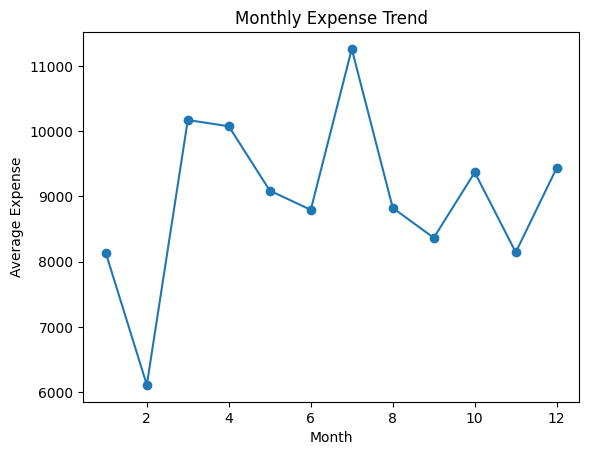

In [8]:
# =========================
# MONTHLY EXPENSE TREND
# =========================

monthly_expense = df.groupby(df['date'].dt.month)['amount'].mean()

monthly_expense.plot(marker='o')

plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Average Expense")

plt.show()

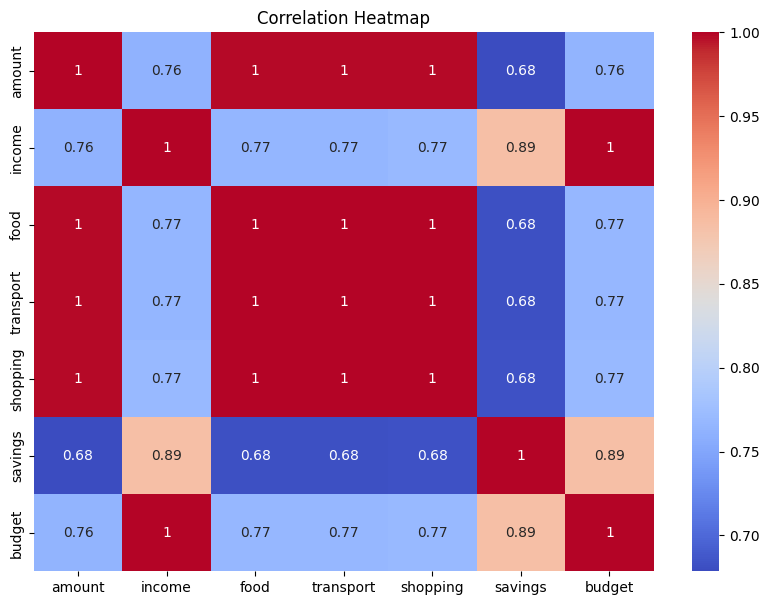

In [9]:
# =========================
# CORRELATION HEATMAP
# =========================

plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

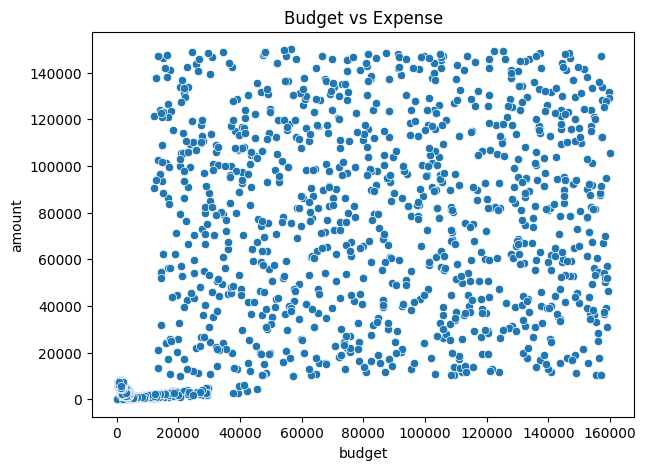

In [10]:
# =========================
# BUDGET VS EXPENSE
# =========================

plt.figure(figsize=(7,5))

sns.scatterplot(
    x='budget',
    y='amount',
    data=df
)

plt.title("Budget vs Expense")

plt.show()

In [11]:

# =========================
# FEATURE ENGINEERING
# =========================

# Month feature
df['month'] = df['date'].dt.month

# Day feature
df['day'] = df['date'].dt.day

# Overspending flag
df['is_overspent'] = (
    df['amount'] > df['budget']
).astype(int)

print(df.head())

        date   amount           category       payment_method   income  \
0 1991-01-01   907.65  Bills & Utilities        Credit (Amex)  13560.0   
1 1991-07-01  1122.15           Shopping   Debit (Mastercard)  14081.2   
2 1991-12-01   366.30           Shopping    Credit (Discover)   2920.0   
3 1992-11-01   170.66  Bills & Utilities         Debit (Visa)   1253.6   
4 1992-12-01    97.35           Shopping  Credit (Mastercard)   1360.0   

     food  transport  shopping  savings   budget day_type  month  day  \
0  226.91      90.76    272.29  2284.59  10170.0  Weekday      1    1   
1  280.54     112.22    336.65  1974.60  10560.9  Weekday      7    1   
2   91.58      36.63    109.89   640.49   2190.0  Weekend     12    1   
3   42.66      17.07     51.20   142.04    940.2  Weekend     11    1   
4   24.34       9.74     29.20   163.20   1020.0  Weekday     12    1   

   is_overspent  
0             0  
1             0  
2             0  
3             0  
4             0  


In [12]:
# =========================
# ENCODE CATEGORICAL DATA
# =========================

df = pd.get_dummies(
    df,
    columns=[
        'category',
        'payment_method',
        'day_type'
    ]
)

print(df.head())

        date   amount   income    food  transport  shopping  savings   budget  \
0 1991-01-01   907.65  13560.0  226.91      90.76    272.29  2284.59  10170.0   
1 1991-07-01  1122.15  14081.2  280.54     112.22    336.65  1974.60  10560.9   
2 1991-12-01   366.30   2920.0   91.58      36.63    109.89   640.49   2190.0   
3 1992-11-01   170.66   1253.6   42.66      17.07     51.20   142.04    940.2   
4 1992-12-01    97.35   1360.0   24.34       9.74     29.20   163.20   1020.0   

   month  day  ...  payment_method_Debit (Mastercard)  \
0      1    1  ...                              False   
1      7    1  ...                               True   
2     12    1  ...                              False   
3     11    1  ...                              False   
4     12    1  ...                              False   

   payment_method_Debit (Prepaid) (Mastercard)  \
0                                        False   
1                                        False   
2                   

In [13]:
# =========================
# FEATURES & TARGET
# =========================

X = df.drop(
    ['amount', 'date'],
    axis=1
)

y = df['amount']

print(X.head())

    income    food  transport  shopping  savings   budget  month  day  \
0  13560.0  226.91      90.76    272.29  2284.59  10170.0      1    1   
1  14081.2  280.54     112.22    336.65  1974.60  10560.9      7    1   
2   2920.0   91.58      36.63    109.89   640.49   2190.0     12    1   
3   1253.6   42.66      17.07     51.20   142.04    940.2     11    1   
4   1360.0   24.34       9.74     29.20   163.20   1020.0     12    1   

   is_overspent  category_Bills & Utilities  ...  \
0             0                        True  ...   
1             0                       False  ...   
2             0                       False  ...   
3             0                        True  ...   
4             0                       False  ...   

   payment_method_Debit (Mastercard)  \
0                              False   
1                               True   
2                              False   
3                              False   
4                              False   

   paym

In [14]:
# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8892, 40)
(2223, 40)


In [15]:
# =========================
# XGBOOST MODEL TRAINING
# =========================

xgb_model = XGBRegressor()

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [16]:
# =========================
# PREDICTIONS
# =========================

predictions = xgb_model.predict(X_test)

print(predictions[:5])

[2352.5015 1499.2151 1653.1412 3261.54   2070.1665]


In [17]:
# =========================
# MODEL EVALUATION
# =========================

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("MAE :", mae)

print("RMSE :", rmse)

MAE : 247.3779729429752
RMSE : 690.6011642641305


In [18]:
# =========================
# RANDOM FOREST
# =========================

X_rf = X

y_rf = df['is_overspent']

In [19]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42
)

In [20]:
rf_model = RandomForestClassifier()

rf_model.fit(
    X_train_rf,
    y_train_rf
)

print("Random Forest Trained")

Random Forest Trained


In [21]:
rf_predictions = rf_model.predict(X_test_rf)

print(rf_predictions[:10])

[0 0 1 1 0 0 0 0 0 0]


In [22]:
accuracy = accuracy_score(
    y_test_rf,
    rf_predictions
)

print("Accuracy :", accuracy)

print(
    classification_report(
        y_test_rf,
        rf_predictions
    )
)

Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1698
           1       1.00      1.00      1.00       525

    accuracy                           1.00      2223
   macro avg       1.00      1.00      1.00      2223
weighted avg       1.00      1.00      1.00      2223



In [23]:
# =========================
# KMEANS CLUSTERING
# =========================

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X)

df['cluster'] = clusters

print(df[['cluster']].head())

   cluster
0        2
1        2
2        2
3        2
4        2


In [24]:
score = silhouette_score(
    X,
    clusters
)

print("Silhouette Score :", score)

Silhouette Score : 0.9017305199390732


In [25]:
# =========================
# SAVE MODELS
# =========================

joblib.dump(
    xgb_model,
    "xgboost_model.pkl"
)

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

joblib.dump(
    kmeans,
    "kmeans_model.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


In [26]:
# =========================
# SAVE CLEAN DATASET
# =========================

df.to_csv(
    "cleaned_budget_buddy.csv",
    index=False
)

print("Cleaned Dataset Saved")

Cleaned Dataset Saved


In [27]:
# =========================
# PREDICTION FUNCTION
# =========================

def predict_expense(data):

    prediction = xgb_model.predict(data)

    return prediction